In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from surmof_cavity import eps_cav
import matplotlib as mpl

In [10]:
%config InlineBackend.figure_format='retina'

In [11]:
with open("subdivide.pkl", "rb") as file:
    results = pickle.load(file)

In [12]:
poles = results['poles']
residues = results['residues']
thickness = results['thickness']

In [13]:
to_THz = 300/2/np.pi
ylim = (300, 500)

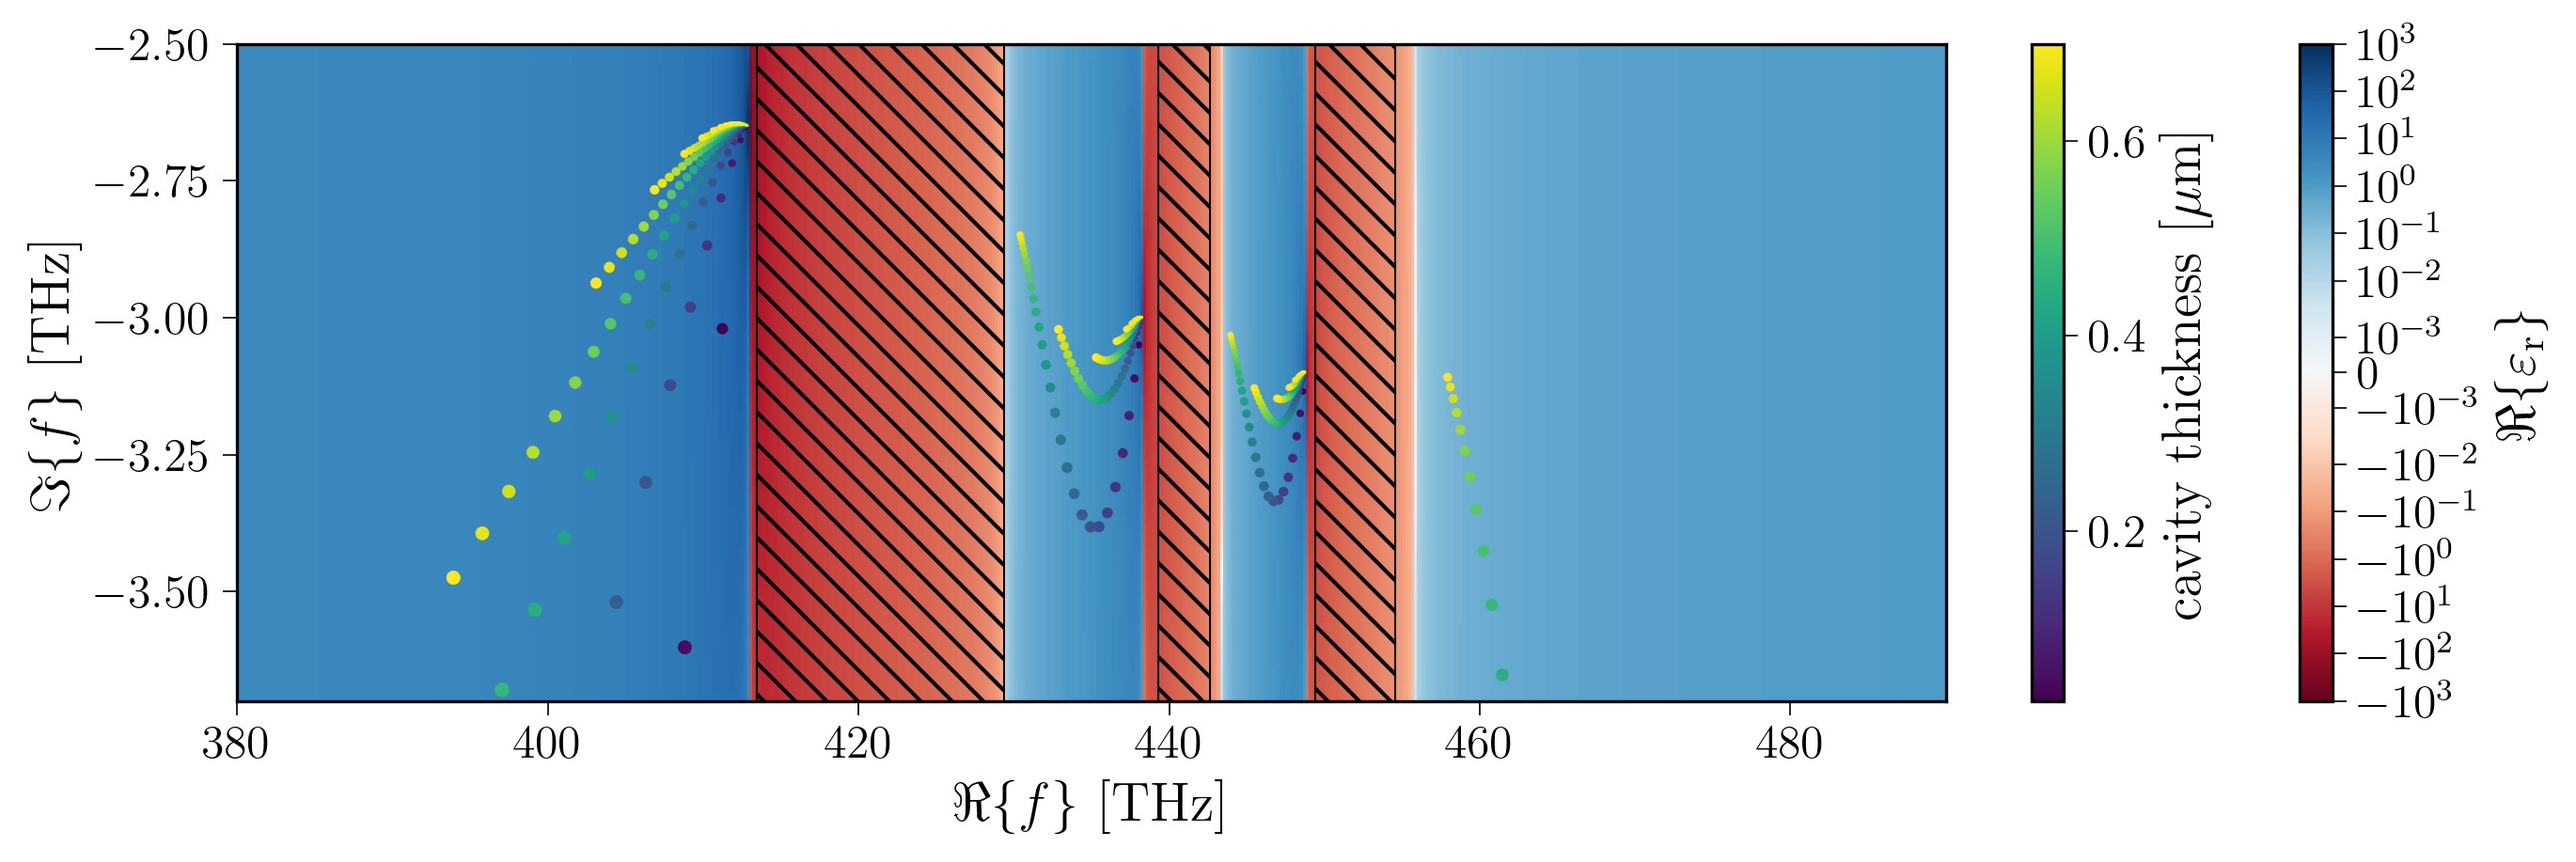

In [17]:
plt.figure(figsize=(9,3), constrained_layout=True)
w_r = np.linspace(380, 490, 600)
w_i = np.linspace(-3.7, -2.5, 200)
W_r, W_i = np.meshgrid(w_r, w_i)
W = W_r +1j*W_i
eps = eps_cav(W/to_THz, 3)

w_r = np.linspace(380, 490, 600)
eps_r = eps_cav(w_r/to_THz, 3)
lines = 0.5*(w_r[:-1]+w_r[1:])[np.diff(eps_r>0)!=0]

plt.pcolormesh(W_r, W_i, np.real(eps), norm=mpl.colors.SymLogNorm(linthresh=0.0015,
                                              vmin=-1000.0, vmax=1000.0, base=10), cmap="RdBu")
plt.colorbar(label="$\Re\{\\varepsilon_\mathrm{r}\}$")

cmap = mpl.cm.viridis
norm = mpl.colors.Normalize(vmin=min(thickness), vmax=max(thickness))
colors = cmap(norm(thickness))
for color, p, r in zip(colors, poles, residues):
    plt.scatter(p.real*to_THz, p.imag*to_THz, color=color, s=np.sqrt(np.abs(r))*100)

plt.colorbar(mpl.cm.ScalarMappable(cmap=cmap, norm=norm), ax=plt.gca(), label="cavity thickness [$\mathrm{\mu m}$]")

plt.xlabel("$\Re\{f\}$ [THz]")
plt.ylabel("$\Im\{f\}$ [THz]")
plt.xlim(380, 490)
plt.ylim(-3.7, -2.5)
plt.savefig("pole_movement.png", dpi=600)

plt.fill_between(w_r, 0, 1, hatch="\\\\\\", where=eps_r.real<0, color="none", edgecolor="k", transform=plt.gca().get_xaxis_transform(), lw=0.5)
plt.savefig("surmof_eps_real.pdf")

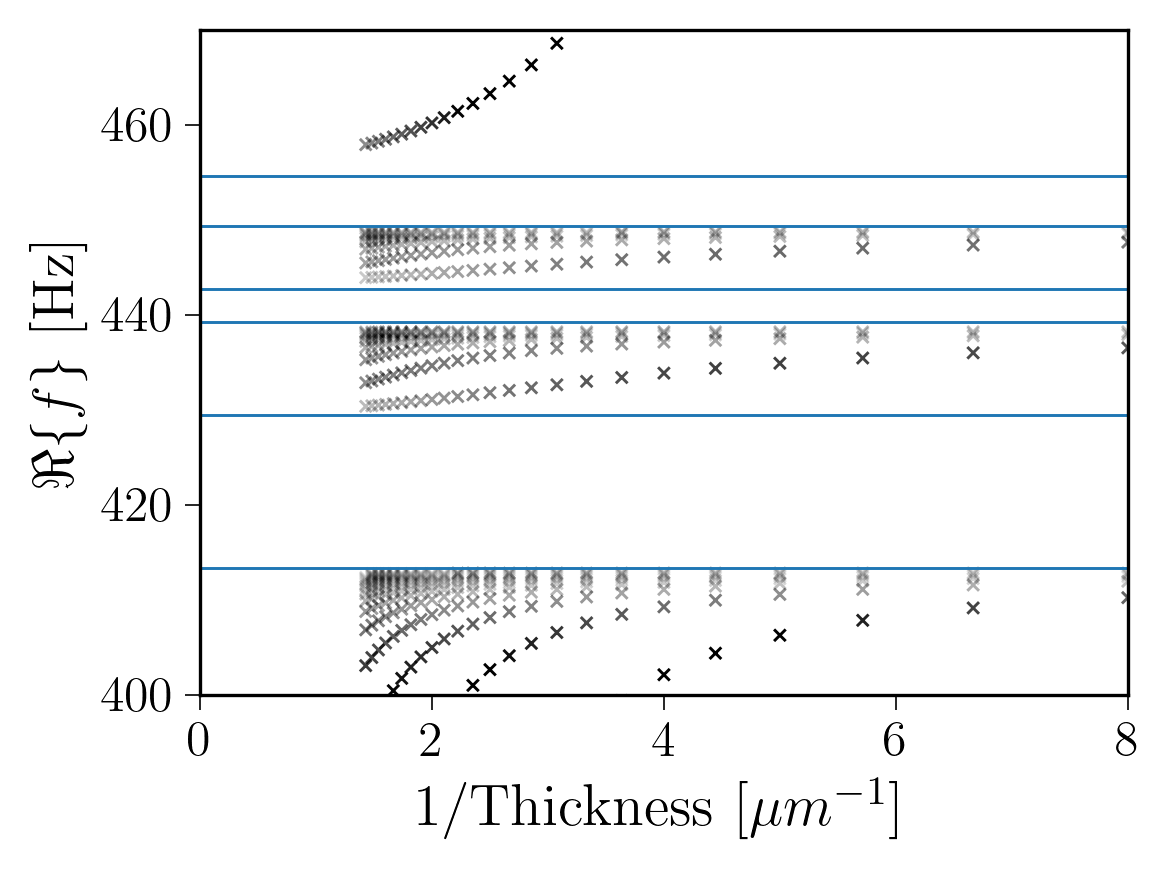

In [18]:
ylim=(400, 470)
for t, p, r in zip(thickness, poles, residues):
    plt.scatter([1/t]*len(p), np.real(p)*to_THz, color="k", marker="x", 
                alpha=np.clip(10*np.sqrt(np.abs(r)), 0, 1))

for line in lines:
    plt.axhline(line)

plt.xlim(0, 8)
plt.ylabel("$\Re\{f\}$ [Hz]")
plt.xlabel("1/Thickness [$\mu m^{-1}$]")
plt.ylim(ylim)
plt.savefig("poles_inverse_thickness.pdf")

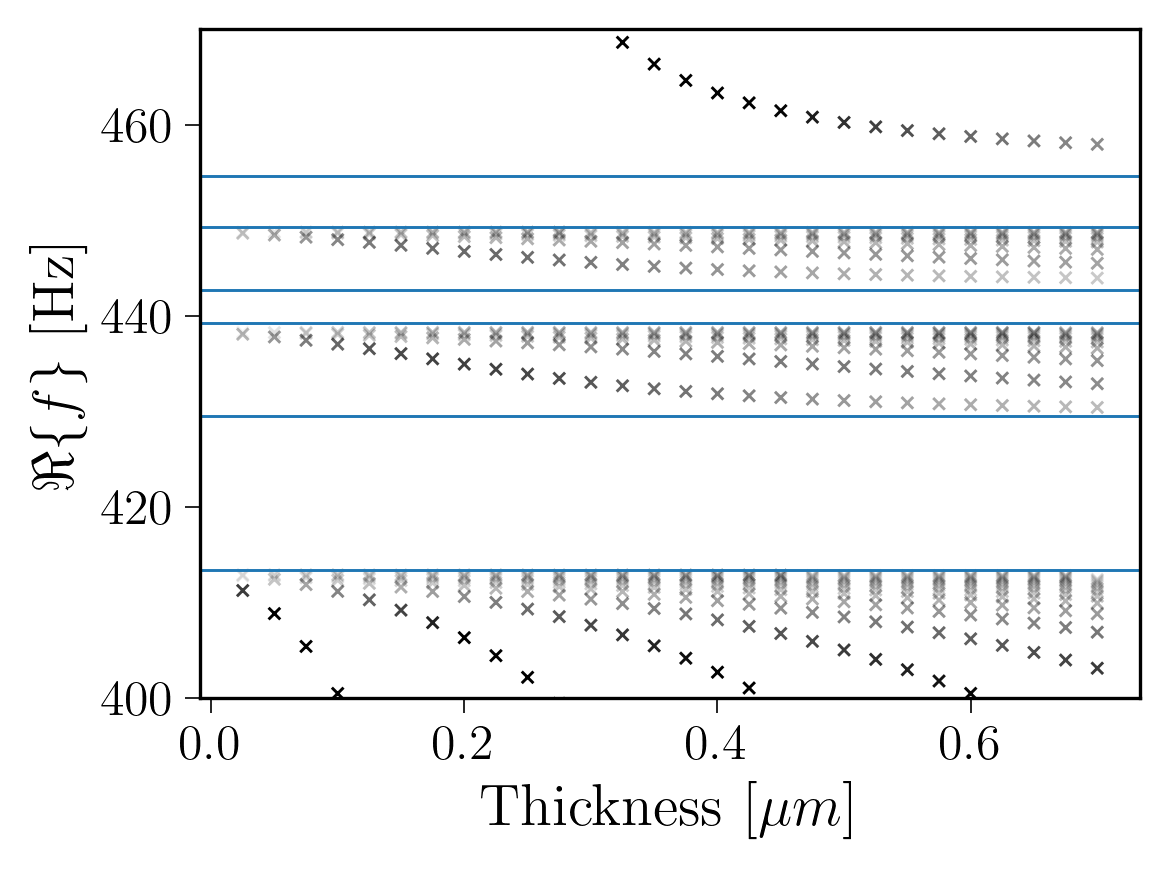

In [19]:
for t, p, r in zip(thickness, poles, residues):
    plt.scatter([t]*len(p), np.real(p)*to_THz, color="k", marker="x", alpha=np.clip(10*np.sqrt(np.abs(r)), 0, 1))

for line in lines:
    plt.axhline(line)

plt.ylabel("$\Re\{f\}$ [Hz]")
plt.xlabel("Thickness [$\mu m$]")
plt.ylim(ylim)
plt.savefig("poles_vs_thickness.pdf")